In [1]:
# 必要なライブラリのインポート
from torch_geometric.datasets import Planetoid

# torch_geometric の Dataset としてダウンロード
dataset = Planetoid(root="./dataset", name="Cora", split="full")

Processing...
Done!


In [2]:
from torch_geometric.transforms import RandomNodeSplit

# ノードを学習データとテストデータに分割
node_splitter = RandomNodeSplit(
    split="train_rest",  # 分割方法
    num_splits=1,  # 分割数
    num_val=0.0,  # 検証データの割合
    num_test=0.4,  # テストデータの割合
    key="y",  # 正解データの属性名
)
splitted_data = node_splitter(dataset._data)
print(splitted_data.node_attrs())
print(splitted_data.train_mask)
print(splitted_data.test_mask)

['test_mask', 'y', 'val_mask', 'x', 'train_mask']
tensor([False, False,  True,  ...,  True,  True, False])
tensor([ True,  True, False,  ..., False, False,  True])


In [3]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, Sequential


# GCNモデルの定義
class GCN(torch.nn.Module):
    def __init__(
        self,
        num_node_features: int,  # 入力層の次元数 = ノードの特徴量の次元数
        projection_dim: int,  # 中間層の次元数
        num_classes: int,  # 出力層の次元数 = 分類先のクラス数
    ) -> None:
        super().__init__()
        self.conv1 = GCNConv(num_node_features, projection_dim)
        self.conv2 = GCNConv(projection_dim, num_classes)

    def forward(self, data: Data) -> torch.Tensor:
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

In [4]:
# GCNモデルのインスタンス化
device = "cuda" if torch.cuda.is_available() else "cpu"
gcn_model = GCN(
    num_node_features=dataset.num_node_features,
    projection_dim=64,
    num_classes=dataset.num_classes,
).to(device)

# 最適化アルゴリズムの選択
gcn_optimizer = torch.optim.Adam(list(gcn_model.parameters()), lr=0.01)

In [5]:
from tqdm import tqdm


# GCNの学習を行う関数の定義
def train_gcn() -> float:
    gcn_model.train()
    total_loss = 0.0
    gcn_optimizer.zero_grad()
    out = gcn_model(splitted_data)
    loss = F.cross_entropy(
        out[splitted_data.train_mask],
        splitted_data.y[splitted_data.train_mask],
    )
    loss.backward()
    gcn_optimizer.step()
    return loss.item()


# GCNの学習の実行
for epoch in tqdm(range(200)):
    loss = train_gcn()
    print(f"train loss : {loss:.4f}")

  4%|▍         | 9/200 [00:00<00:04, 38.63it/s]

train loss : 1.9533
train loss : 1.7212
train loss : 1.5123
train loss : 1.3116
train loss : 1.1044
train loss : 0.9286
train loss : 0.7883
train loss : 0.6494
train loss : 0.5612
train loss : 0.4953
train loss : 0.4147
train loss : 0.3790
train loss : 0.3479
train loss : 0.3268
train loss : 0.3067
train loss : 0.2813


 12%|█▎        | 25/200 [00:00<00:02, 58.94it/s]

train loss : 0.2720
train loss : 0.2510
train loss : 0.2443
train loss : 0.2260
train loss : 0.2244
train loss : 0.2202
train loss : 0.2022
train loss : 0.2002
train loss : 0.1849
train loss : 0.1877
train loss : 0.1756
train loss : 0.1596
train loss : 0.1613
train loss : 0.1554


 20%|██        | 41/200 [00:00<00:02, 67.99it/s]

...

train loss : 0.0232
train loss : 0.0220
train loss : 0.0243
train loss : 0.0197
train loss : 0.0229
train loss : 0.0191
train loss : 0.0198
train loss : 0.0212
train loss : 0.0189
train loss : 0.0174


 94%|█████████▎| 187/200 [00:02<00:00, 57.02it/s]

train loss : 0.0197
train loss : 0.0193
train loss : 0.0197
train loss : 0.0193
train loss : 0.0204
train loss : 0.0190
train loss : 0.0182
train loss : 0.0175
train loss : 0.0202
train loss : 0.0183
train loss : 0.0213
train loss : 0.0195
train loss : 0.0180
train loss : 0.0178


100%|██████████| 200/200 [00:03<00:00, 62.77it/s]

train loss : 0.0159
train loss : 0.0167
train loss : 0.0194
train loss : 0.0174
train loss : 0.0151
train loss : 0.0197
train loss : 0.0180
train loss : 0.0185


In [6]:
from sklearn.metrics import classification_report

y_true = splitted_data.y[splitted_data.test_mask].numpy()

# 評価データに対する推論
with torch.no_grad():
    gcn_model.eval()
    out = gcn_model(splitted_data)
    y_pred = out.argmax(dim=1)[splitted_data.test_mask]

# 評価結果の表示
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79       155
           1       0.86      0.86      0.86        83
           2       0.90      0.96      0.93       157
           3       0.89      0.87      0.88       328
           4       0.83      0.87      0.85       175
           5       0.83      0.88      0.85       120
           6       0.83      0.85      0.84        65

    accuracy                           0.86      1083
   macro avg       0.86      0.86      0.86      1083
weighted avg       0.86      0.86      0.86      1083



In [7]:
from torch_geometric.nn import SAGEConv


# GraphSAGEモデルの定義
class GraphSAGE(torch.nn.Module):

    def __init__(
        self,
        num_node_features: int,  # 入力層の次元数 = ノードの特徴量の次元数
        projection_dim: int,  # 中間層の次元数
        num_classes: int,  # 出力層の次元数 = 分類先のクラス数
    ) -> None:
        super().__init__()
        self.conv1 = SAGEConv(num_node_features, projection_dim)
        self.conv2 = SAGEConv(projection_dim, num_classes)

    def forward(self, data: Data) -> torch.Tensor:
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)

In [8]:
# GraphSAGEモデルのインスタンス化
device = "cuda" if torch.cuda.is_available() else "cpu"
sage_model = GraphSAGE(
    num_node_features=dataset.num_node_features,
    projection_dim=64,
    num_classes=dataset.num_classes,
).to(device)
sage_optimizer = torch.optim.Adam(list(sage_model.parameters()), lr=0.01)

In [9]:
# GraphSAGEモデルの学習を行う関数の定義
def train_sage() -> float:
    sage_model.train()
    total_loss = 0
    sage_optimizer.zero_grad()
    out = sage_model(splitted_data)
    loss = F.cross_entropy(
        out[splitted_data.train_mask],
        splitted_data.y[splitted_data.train_mask],
    )
    loss.backward()
    sage_optimizer.step()
    return loss.item()


# GraphSAGEモデルの学習の実行
for epoch in tqdm(range(1, 201)):
    loss = train_sage()
    print(f"train loss : {loss:.4f}")

  2%|▏         | 4/200 [00:00<00:11, 17.02it/s]

train loss : 1.9566
train loss : 1.6388
train loss : 1.3554
train loss : 1.0460
train loss : 0.7917
train loss : 0.6029
train loss : 0.4512


  6%|▌         | 11/200 [00:00<00:07, 25.63it/s]

train loss : 0.3507
train loss : 0.2877
train loss : 0.2445
train loss : 0.2005
train loss : 0.1776
train loss : 0.1466


  9%|▉         | 18/200 [00:00<00:06, 28.60it/s]

...

train loss : 0.0005
train loss : 0.0010
train loss : 0.0010
train loss : 0.0010
train loss : 0.0013
train loss : 0.0012
train loss : 0.0011


 97%|█████████▋| 194/200 [00:07<00:00, 32.57it/s]

train loss : 0.0010
train loss : 0.0008
train loss : 0.0009
train loss : 0.0007
train loss : 0.0012
train loss : 0.0007
train loss : 0.0008


100%|██████████| 200/200 [00:07<00:00, 26.48it/s]

train loss : 0.0007
train loss : 0.0010
train loss : 0.0009
train loss : 0.0008


In [10]:
from sklearn.metrics import classification_report
from sklearn.utils.validation import column_or_1d

y_true = column_or_1d(splitted_data.y[splitted_data.test_mask].numpy())

# 評価データに対する推論
with torch.no_grad():
    sage_model.eval()
    out = sage_model(splitted_data)
    y_pred = out.argmax(dim=1)[splitted_data.test_mask]

# 評価結果の表示
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.75      0.80       155
           1       0.89      0.84      0.86        83
           2       0.95      0.94      0.95       157
           3       0.88      0.91      0.90       328
           4       0.85      0.88      0.86       175
           5       0.87      0.88      0.87       120
           6       0.83      0.89      0.86        65

    accuracy                           0.88      1083
   macro avg       0.87      0.87      0.87      1083
weighted avg       0.88      0.88      0.88      1083



In [11]:
from torch_geometric.transforms import RandomLinkSplit

# エッジを学習データとテストデータに分割
link_splitter = RandomLinkSplit(
    num_val=0.0,  # 検証データの割合
    num_test=0.4,  # テストデータの割合
    is_undirected=True,  # 無向ネットワークかどうか
)
train_data, _, test_data = link_splitter(dataset._data)
# 学習に用いるエッジを示す配列の形状
print(train_data.edge_label_index.shape)
# テストに用いるエッジ示す配列の形状
print(test_data.edge_label_index.shape)

torch.Size([2, 6334])
torch.Size([2, 4222])


In [12]:
# GCNによる特徴変換の定義
class GCNLayer(torch.nn.Module):

    def __init__(
        self,
        num_node_features: int,  # 入力層の次元数 = ノードの特徴量の次元数
        projection_dim: int,  # 中間層の次元数
    ) -> None:
        super().__init__()
        self.conv1 = GCNConv(num_node_features, projection_dim)
        self.conv2 = GCNConv(projection_dim, projection_dim)

    def forward(self, data: Data) -> torch.Tensor:
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        return self.conv2(x, edge_index)


# リンク予測モデルの定義
class LinkPredModel(torch.nn.Module):
    def __init__(
        self,
        num_node_features: int,
        projection_dim: int,
    ) -> None:
        super().__init__()
        self.gcn_layer = GCNLayer(num_node_features, projection_dim)

    def forward(self, data: Data, edge_label_index: torch.Tensor) -> None:
        x = self.gcn_layer(data)
        x_src = x[edge_label_index[0]]
        x_dst = x[edge_label_index[1]]
        # 内積をシグモイド関数に入力して、0〜1の値に変換
        return F.sigmoid((x_src * x_dst).sum(-1))

In [14]:
# リンク予測モデルのインスタンス化
device = "cuda" if torch.cuda.is_available() else "cpu"
link_pred_model = LinkPredModel(
    num_node_features=dataset.num_node_features,
    projection_dim=64,
).to(device)

# 最適化アルゴリズムの選択
link_pred_optimizer = torch.optim.Adam(list(link_pred_model.parameters()), lr=0.01)

In [15]:
from torch_geometric.utils import negative_sampling


# リンク予測モデルを学習する関数の定義
def train_link_pred_model() -> float:
    link_pred_model.train()
    link_pred_optimizer.zero_grad()

    total_loss = 0
    link_pred_optimizer.zero_grad()

    # ネガティブサンプリングによる負例の獲得
    negative_edge_index = negative_sampling(
        edge_index=train_data.edge_index,
        num_nodes=train_data.num_nodes,
        num_neg_samples=train_data.edge_label_index.size(1),
        method="sparse",
    )

    # 学習対象のエッジのインデックス
    edge_label_index = torch.cat(
        [train_data.edge_label_index, negative_edge_index],
        dim=-1,
    )

    # 学習対象のエッジのラベル
    # 1は実在するリンク、0はランダムに選ばれたノード間のリンク
    edge_label = torch.cat(
        [
            train_data.edge_label,
            train_data.edge_label.new_zeros(negative_edge_index.size(1)),
        ],
        dim=0,
    )
    out = link_pred_model(train_data, edge_label_index)
    loss = F.binary_cross_entropy(out, edge_label)
    loss.backward()
    link_pred_optimizer.step()
    total_loss += loss.item()
    return total_loss


# リンク予測モデルの学習の実行
for epoch in range(1, 31):
    loss = train_link_pred_model()
    print(f"train loss : {loss:.4f}")

train loss : 0.7146
train loss : 0.7764
train loss : 0.7009
train loss : 0.6930
train loss : 0.6943
train loss : 0.6942
train loss : 0.6934
train loss : 0.6911
train loss : 0.6873
train loss : 0.6817
train loss : 0.6743
train loss : 0.6685
train loss : 0.6555
train loss : 0.6451
train loss : 0.6442
train loss : 0.6361
train loss : 0.6337
train loss : 0.6298
train loss : 0.6294
train loss : 0.6260
train loss : 0.6307
train loss : 0.6146
train loss : 0.6170
train loss : 0.6188
train loss : 0.6162
train loss : 0.6067
train loss : 0.6149
train loss : 0.6068
train loss : 0.6105
train loss : 0.6084


In [16]:
from sklearn.metrics import roc_auc_score

# 評価データに対する推論
with torch.no_grad():
    link_pred_model.eval()
    out = link_pred_model(test_data, test_data.edge_label_index)
    y_true = test_data.edge_label.numpy()
    y_pred = out.numpy()

# AUCの計算
print(f"AUC : {roc_auc_score(y_true, y_pred):.4f}")

AUC : 0.8608


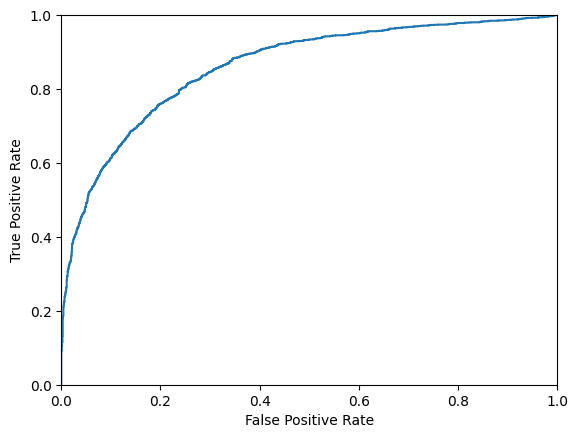

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC曲線の描画
fpr, tpr, _ = roc_curve(y_true, y_pred)
plt.plot(fpr, tpr)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()